In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

from shapely.geometry import box

TILING_RESOLUTION = "i"
TILING_LEVEL = 1
TEST_ZOOMS = [0, 1, 2, 3, 4, 5, 6, 7, 8]

In [2]:
DATA_DIR = Path(r"P:\HACKATHONS\SIH26PS67\DATA\REF")
COASTLINE_DIR = DATA_DIR / "coastline"
GSHHG_DIR = COASTLINE_DIR / "gshhg"   # notice the G at the end

GSHHS_DIR = GSHHG_DIR / "GSHHS_shp"   # notice the S at the end
WDBII_DIR = GSHHG_DIR / "WDBII_shp"

RESOLUTIONS = ["c", "l", "i", "h", "f"]

In [3]:
TILING_RESOLUTION = "i"
TILING_LEVEL = 1

tiling_path = (
    GSHHS_DIR / TILING_RESOLUTION /
    f"GSHHS_{TILING_RESOLUTION}_L{TILING_LEVEL}.shp"
)

gdf_tiles = gpd.read_file(tiling_path)

print(f"Features: {len(gdf_tiles):,}")
print(f"CRS: {gdf_tiles.crs}")

Features: 32,830
CRS: EPSG:4326


In [4]:
gdf_tiles_3857 = gdf_tiles.to_crs("EPSG:3857")

print(gdf_tiles_3857.crs)

EPSG:3857


In [5]:
gdf_tiles_3857.total_bounds

array([-20037508.34278924, -10725923.72211038,  20037508.34278924,
        18428205.56255518])

In [6]:
WEB_MERCATOR_HALF_WORLD = 20037508.342789244
WORLD_SIZE = WEB_MERCATOR_HALF_WORLD * 2


def tile_bounds_xyz(x, y, z):
    """
    Return XYZ tile bounds in EPSG:3857.
    """

    n = 2 ** z

    tile_size = WORLD_SIZE / n

    minx = -WEB_MERCATOR_HALF_WORLD + x * tile_size
    maxx = minx + tile_size

    maxy = WEB_MERCATOR_HALF_WORLD - y * tile_size
    miny = maxy - tile_size

    return (
        minx,
        miny,
        maxx,
        maxy
    )

In [7]:
for z in range(3):

    n = 2 ** z

    print(
        f"z={z}: "
        f"{n} x {n} = {n*n:,} tiles"
    )

z=0: 1 x 1 = 1 tiles
z=1: 2 x 2 = 4 tiles
z=2: 4 x 4 = 16 tiles


In [8]:
def generate_tile_grid(z):

    n = 2 ** z

    records = []

    for y in range(n):

        for x in range(n):

            minx, miny, maxx, maxy = tile_bounds_xyz(
                x, y, z
            )

            records.append({
                "z": z,
                "x": x,
                "y": y,
                "geometry": box(
                    minx,
                    miny,
                    maxx,
                    maxy
                )
            })

    return gpd.GeoDataFrame(
        records,
        geometry="geometry",
        crs="EPSG:3857"
    )

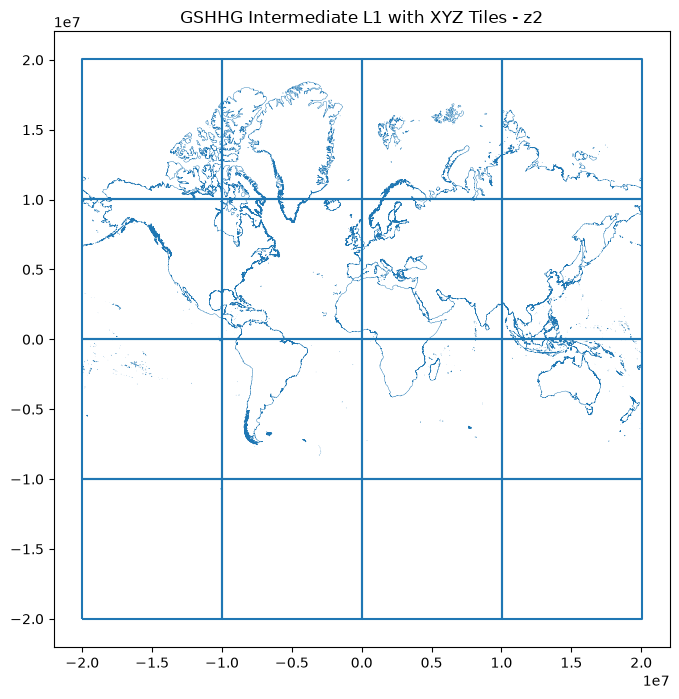

In [9]:
tiles_z2 = generate_tile_grid(2)

ax = tiles_z2.boundary.plot(
    figsize=(14, 8)
)

gdf_tiles_3857.boundary.plot(
    ax=ax,
    linewidth=0.3
)

ax.set_title(
    "GSHHG Intermediate L1 with XYZ Tiles - z2"
)

plt.show()

In [10]:
def assign_features_to_tiles(gdf, z):

    tiles = generate_tile_grid(z)

    joined = gpd.sjoin(
        gdf,
        tiles,
        predicate="intersects",
        how="inner"
    )

    return joined

In [11]:
tile_assignments_z2 = assign_features_to_tiles(
    gdf_tiles_3857,
    2
)

print(
    f"Source features: {len(gdf_tiles_3857):,}"
)

print(
    f"Feature-tile assignments: "
    f"{len(tile_assignments_z2):,}"
)

Source features: 32,830
Feature-tile assignments: 32,902


In [12]:
tile_feature_counts = (
    tile_assignments_z2
    .groupby(["z", "x", "y"])
    .size()
    .rename("feature_count")
    .reset_index()
)

tile_feature_counts.head()

,z,x,y,feature_count
0,2,0,0,1704
1,2,0,1,2197
2,2,0,2,505
3,2,0,3,1
4,2,1,0,1392


In [13]:
tile_feature_counts["feature_count"].describe(
    percentiles=[
        0.5,
        0.9,
        0.95,
        0.99
    ]
)

count      13.000000
mean     2530.923077
std      2264.978199
min         1.000000
50%      1704.000000
90%      5406.400000
95%      6165.800000
99%      7013.960000
max      7226.000000
Name: feature_count, dtype: float64

In [14]:
def tile_occupancy(z, gdf):

    tiles = generate_tile_grid(z)

    assignments = gpd.sjoin(
        gdf,
        tiles,
        predicate="intersects",
        how="inner"
    )

    occupied = (
        assignments[
            ["z", "x", "y"]
        ]
        .drop_duplicates()
    )

    occupied_count = len(occupied)
    total_count = len(tiles)

    return {
        "zoom": z,
        "total_tiles": total_count,
        "occupied_tiles": occupied_count,
        "empty_tiles": total_count - occupied_count,
        "occupancy_pct": occupied_count / total_count * 100
    }

In [15]:
occupancy_z2 = tile_occupancy(
    2,
    gdf_tiles_3857
)

occupancy_z2

{'zoom': 2,
 'total_tiles': 16,
 'occupied_tiles': 13,
 'empty_tiles': 3,
 'occupancy_pct': 81.25}

In [16]:
occupancy_results = []

for z in TEST_ZOOMS:

    print(f"Processing zoom {z}...")

    result = tile_occupancy(
        z,
        gdf_tiles_3857
    )

    occupancy_results.append(result)

occupancy_df = pd.DataFrame(
    occupancy_results
)

occupancy_df

Processing zoom 0...
Processing zoom 1...
Processing zoom 2...
Processing zoom 3...
Processing zoom 4...
Processing zoom 5...
Processing zoom 6...
Processing zoom 7...
Processing zoom 8...


,zoom,total_tiles,occupied_tiles,empty_tiles,occupancy_pct
0,0,1,1,0,100.000000
1,1,4,4,0,100.000000
2,2,16,13,3,81.250000
3,3,64,45,19,70.312500
4,4,256,149,107,58.203125
5,5,1024,455,569,44.433594
6,6,4096,1436,2660,35.058594
7,7,16384,4758,11626,29.040527
8,8,65536,16672,48864,25.439453


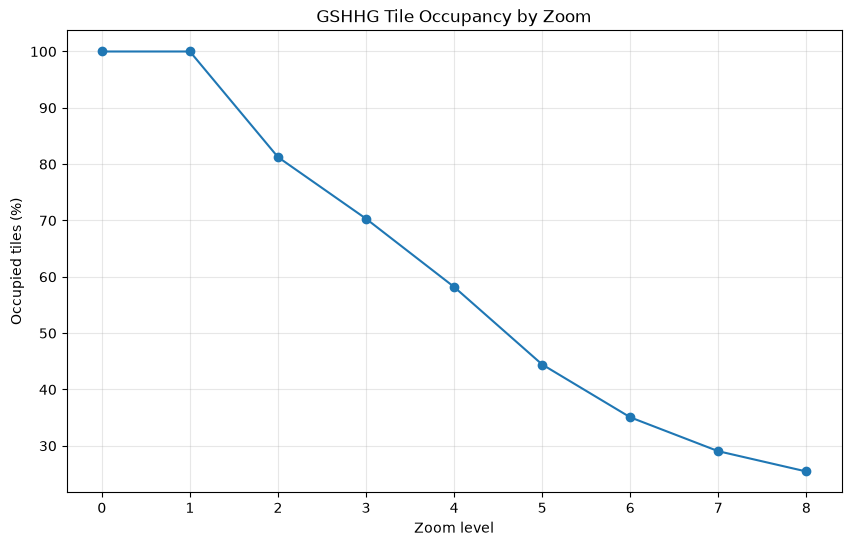

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    occupancy_df["zoom"],
    occupancy_df["occupancy_pct"],
    marker="o"
)

plt.xlabel("Zoom level")
plt.ylabel("Occupied tiles (%)")
plt.title("GSHHG Tile Occupancy by Zoom")

plt.xticks(TEST_ZOOMS)
plt.grid(True, alpha=0.3)

plt.show()

In [18]:
tile_amplification_results = []

for z in TEST_ZOOMS:

    assignments = assign_features_to_tiles(
        gdf_tiles_3857,
        z
    )

    amplification = (
        len(assignments) /
        len(gdf_tiles_3857)
    )

    tile_amplification_results.append({
        "zoom": z,
        "source_features": len(gdf_tiles_3857),
        "feature_tile_assignments": len(assignments),
        "amplification_factor": amplification
    })

amplification_df = pd.DataFrame(
    tile_amplification_results
)

amplification_df

,zoom,source_features,feature_tile_assignments,amplification_factor
0,0,32830,32830,1.000000
1,1,32830,32857,1.000822
2,2,32830,32902,1.002193
3,3,32830,32959,1.003929
4,4,32830,33159,1.010021
5,5,32830,33617,1.023972
6,6,32830,34844,1.061346
7,7,32830,38637,1.176881
8,8,32830,51183,1.559031


In [19]:
def clip_features_to_tiles(gdf, z):

    tiles = generate_tile_grid(z)

    assignments = gpd.sjoin(
        gdf,
        tiles,
        predicate="intersects",
        how="inner"
    )

    clipped_records = []

    for idx, row in tqdm(
        assignments.iterrows(),
        total=len(assignments),
        desc=f"Clipping z{z}"
    ):

        tile_geometry = tiles.loc[
            row["index_right"],
            "geometry"
        ]

        source_geometry = row.geometry

        clipped = source_geometry.intersection(
            tile_geometry
        )

        if clipped.is_empty:
            continue

        clipped_records.append({
            "z": z,
            "x": row["x"],
            "y": row["y"],
            "source_index": idx,
            "geometry": clipped
        })

    return gpd.GeoDataFrame(
        clipped_records,
        geometry="geometry",
        crs=gdf.crs
    )

In [21]:
def clip_features_to_tiles(gdf, z):
    tiles = generate_tile_grid(z)

    assignments = gpd.sjoin(
        gdf,
        tiles,
        predicate="intersects",
        how="inner"
    )

    clipped_records = []
    failed_records = []

    for idx, row in tqdm(
        assignments.iterrows(),
        total=len(assignments),
        desc=f"Clipping z{z}"
    ):
        tile_geometry = tiles.loc[row["index_right"], "geometry"]
        source_geometry = row.geometry

        try:
            clipped = source_geometry.intersection(tile_geometry)

        except Exception as e:
            failed_records.append({
                "source_index": idx,
                "tile_x": row["x"],
                "tile_y": row["y"],
                "error": str(e),
                "geometry": source_geometry
            })
            continue

        if clipped.is_empty:
            continue

        clipped_records.append({
            "z": z,
            "x": row["x"],
            "y": row["y"],
            "source_index": idx,
            "geometry": clipped
        })

    clipped_gdf = gpd.GeoDataFrame(
        clipped_records,
        geometry="geometry",
        crs=gdf.crs
    )

    failed_gdf = gpd.GeoDataFrame(
        failed_records,
        geometry="geometry",
        crs=gdf.crs
    )

    return clipped_gdf, failed_gdf

In [22]:
clipped_z2, failed_z2 = clip_features_to_tiles(
    gdf_tiles_3857,
    2
)

Clipping z2:   0%|          | 0/32902 [00:00<?, ?it/s]

In [23]:
print("Successful clips:", len(clipped_z2))
print("Failed clips:", len(failed_z2))

Successful clips: 32901
Failed clips: 1


In [24]:
failed_z2[
    ["source_index", "tile_x", "tile_y", "error"]
].head(20)

,source_index,tile_x,tile_y,error
0,2244,1,1,TopologyException: side location conflict at -...


In [25]:
failed_z2.geometry.is_valid.value_counts()

False    1
Name: count, dtype: int64

In [26]:
from shapely.validation import explain_validity

failed_z2["validity_reason"] = failed_z2.geometry.apply(
    explain_validity
)

failed_z2[
    ["source_index", "validity_reason"]
].head(20)

,source_index,validity_reason
0,2244,Self-intersection[-7765852.41775161 5427829.16...


In [27]:
gdf_tiles_3857

,id,level,source,parent_id,sibling_id,area,geometry
0,0-E,1,WVS,-1,0,5.065405e+07,"POLYGON ((20037508.343 10748854.074, 20037508...."
1,0-W,1,WVS,-1,0,5.065405e+07,"POLYGON ((-20037508.343 10748854.074, -2003733..."
2,1,1,WVS,-1,1,2.922097e+07,"POLYGON ((3594902.655 3660294.391, 3593894.212..."
3,2,1,WVS,-1,2,2.015474e+07,"POLYGON ((-8900240.641 1041906.07, -8897252.15..."
4,3,1,WVS,-1,3,1.753416e+07,"POLYGON ((-8166589.537 -6983075.054, -8166688...."
...,...,...,...,...,...,...,...
32825,33248,1,WVS,-1,69443,1.454036e-01,"POLYGON ((-8661398.551 3127279.339, -8661376.8..."
32826,33249,1,WVS,-1,70570,1.412749e-01,"POLYGON ((14946728.879 790616.578, 14946728.87..."
32827,33250,1,WVS,-1,73276,1.323911e-01,"POLYGON ((-8610271.958 9654574.692, -8610231.7..."
32828,33251,1,WVS,-1,79124,1.161930e-01,"POLYGON ((16478577.802 -658977.741, 16478627.3..."


In [28]:
print("Original CRS:", gdf_tiles.crs)
print("Original invalid:", (~gdf_tiles.geometry.is_valid).sum())

print("3857 invalid:", (~gdf_tiles_3857.geometry.is_valid).sum())

Original CRS: EPSG:4326
Original invalid: 1
3857 invalid: 1


In [29]:
clipped_z2 = clip_features_to_tiles(
    gdf_tiles_3857,
    2
)

Clipping z2:   0%|          | 0/32902 [00:00<?, ?it/s]

In [30]:
print(len(clipped_z2))

2


In [31]:
clipped_z3 = clip_features_to_tiles(
    gdf_tiles_3857,
    3
)

Clipping z3:   0%|          | 0/32959 [00:00<?, ?it/s]

In [32]:
def count_ring_vertices(ring):
    return len(ring.coords)


def count_polygon_vertices(polygon):

    count = count_ring_vertices(
        polygon.exterior
    )

    for interior in polygon.interiors:
        count += len(interior.coords)

    return count


def count_geometry_vertices(geometry):

    if geometry is None or geometry.is_empty:
        return 0

    geometry_type = geometry.geom_type

    if geometry_type == "Polygon":
        return count_polygon_vertices(geometry)

    if geometry_type == "MultiPolygon":
        return sum(
            count_polygon_vertices(polygon)
            for polygon in geometry.geoms
        )

    if hasattr(geometry, "geoms"):
        return sum(
            count_geometry_vertices(part)
            for part in geometry.geoms
        )

    if hasattr(geometry, "coords"):
        return len(geometry.coords)

    return 0

In [34]:
clipped_z2, failed_z2 = clip_features_to_tiles(
    gdf_tiles_3857,
    2
)

Clipping z2:   0%|          | 0/32902 [00:00<?, ?it/s]

In [35]:
clipped_z2["vertex_count"] = (
    clipped_z2.geometry.apply(
        count_geometry_vertices
    )
)

In [36]:
clipped_z2["vertex_count"].describe(
    percentiles=[
        0.5,
        0.9,
        0.95,
        0.99
    ]
)

count    32901.000000
mean        10.361873
std        160.855848
min          1.000000
50%          4.000000
90%          8.000000
95%         14.000000
99%         49.000000
max      16102.000000
Name: vertex_count, dtype: float64

In [37]:
tile_vertex_stats_z2 = (
    clipped_z2
    .groupby(["z", "x", "y"])
    .agg(
        feature_count=("source_index", "size"),
        vertex_count=("vertex_count", "sum")
    )
    .reset_index()
)

tile_vertex_stats_z2.head()

,z,x,y,feature_count,vertex_count
0,2,0,0,1704,17503
1,2,0,1,2197,27383
2,2,0,2,505,3011
3,2,0,3,1,8
4,2,1,0,1392,17801


In [38]:
tile_vertex_stats_z2[
    ["feature_count", "vertex_count"]
].describe(
    percentiles=[
        0.5,
        0.9,
        0.95,
        0.99
    ]
)

,feature_count,vertex_count
count,13.000000,13.000000
mean,2530.846154,26224.307692
std,2264.805468,22138.273383
min,1.000000,8.000000
50%,1704.000000,17801.000000
90%,5406.400000,50624.200000
95%,6165.400000,59571.000000
99%,7013.080000,69975.000000
max,7225.000000,72576.000000


In [39]:
heaviest_tiles = (
    tile_vertex_stats_z2
    .sort_values(
        "vertex_count",
        ascending=False
    )
    .head(20)
)

heaviest_tiles

,z,x,y,feature_count,vertex_count
5,2,1,1,7225,72576
11,2,3,1,5196,50901
8,2,2,1,5459,49517
12,2,3,2,3964,43776
6,2,1,2,2840,30422
1,2,0,1,2197,27383
4,2,1,0,1392,17801
0,2,0,0,1704,17503
7,2,2,0,1100,13484
10,2,3,0,799,7314


In [40]:
tiles_z2 = generate_tile_grid(2)

tile_load = tiles_z2.merge(
    tile_vertex_stats_z2,
    on=["z", "x", "y"],
    how="left"
)

tile_load["vertex_count"] = (
    tile_load["vertex_count"]
    .fillna(0)
)

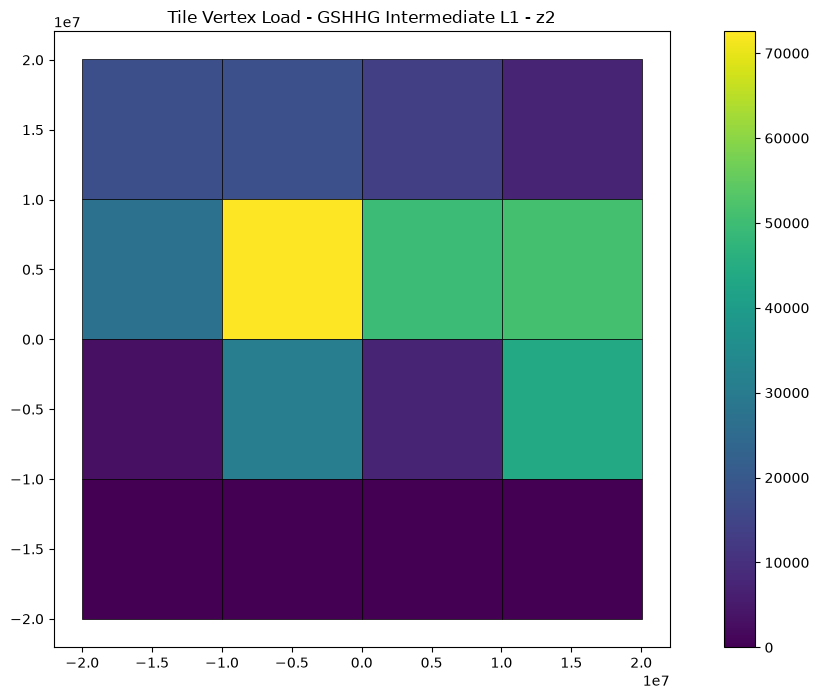

In [41]:
fig, ax = plt.subplots(
    figsize=(14, 8)
)

tile_load.plot(
    ax=ax,
    column="vertex_count",
    legend=True,
    edgecolor="black",
    linewidth=0.5
)

ax.set_title(
    "Tile Vertex Load - GSHHG Intermediate L1 - z2"
)

plt.show()

In [42]:
source_vertex_counts = (
    gdf_tiles_3857.geometry
    .apply(count_geometry_vertices)
)

source_vertex_counts = (
    source_vertex_counts
    .rename("original_vertex_count")
)

clipped_vertex_totals = (
    clipped_z2
    .groupby("source_index")["vertex_count"]
    .sum()
    .rename("clipped_vertex_count")
)

clipping_overhead = pd.concat(
    [
        source_vertex_counts,
        clipped_vertex_totals
    ],
    axis=1
).fillna(0)

clipping_overhead["vertex_amplification"] = (
    clipping_overhead["clipped_vertex_count"] /
    clipping_overhead["original_vertex_count"]
)

clipping_overhead.describe()

,original_vertex_count,clipped_vertex_count,vertex_amplification
count,32830.000000,32830.000000,32830.000000
mean,10.367316,10.384283,1.000784
std,254.682061,255.327303,0.025125
min,4.000000,0.000000,0.000000
25%,4.000000,4.000000,1.000000
50%,4.000000,4.000000,1.000000
75%,5.000000,5.000000,1.000000
max,34332.000000,34398.000000,2.250000
